<a href="https://colab.research.google.com/github/NeelGaji/CS-GY-6923-Machine-Learning/blob/main/lab4_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 4: Fitting an MLP to regression data

In this lab, you will implement and a train a simple neural network in PyTorch. Then, you will study how the function approximation capabilities of this model are affected by the model width and depth.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

Let's create some regression data using a complicated function. There will be no test data, just the train set that we will try to fit.

Text(0, 0.5, 'y')

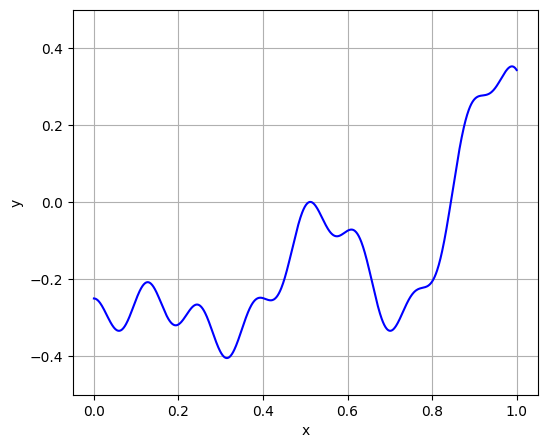

In [5]:
def f(x):
  return 0.2 + 0.4 * x**2 + 0.3 * x * torch.sin(15 * x)+ 0.05 * torch.cos(50*x) - 0.5

x = torch.linspace(0, 1, 1000)
fs = f(x)

_, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x, fs, "-b")
ax.grid()
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")


Complete the function below. See the docstring for detailed instructions. Make sure that the training works and you get a reasonable fit when you run the function with the provided parameters.

Sequential(
  (0): Linear(in_features=1, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=1, bias=True)
)


Text(0, 0.5, 'y')

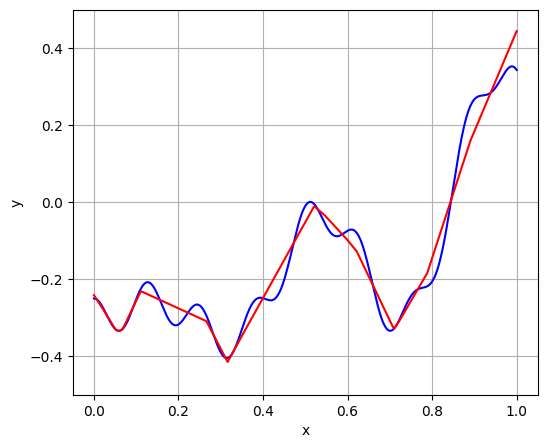

In [7]:
def train_model(
    x: torch.Tensor,
    y: torch.Tensor,
    width: int,
    num_hidden_layers: int,
    epochs: int = 1000,
    activation=nn.ReLU,
    lr: float=0.01,
    ):
  """
    Train a fully connected neural network for regression tasks using PyTorch.

    This function constructs a feedforward neural network with a specified architecture,
    trains it using the Adam optimizer and mean squared error loss, and returns both
    the trained model and its predictions on the input data.

    Architecture:
        - Input layer: Linear(1, width) → Activation
        - Hidden layers: [Linear(width, width) → Activation] × num_hidden_layers
        - Output layer: Linear(width, 1) (no activation)

    The network expects 1-dimensional input features and produces scalar outputs.

    Parameters
    ----------
    x : torch.Tensor
        Input training data of shape (n_samples, 1) or (n_samples,).
        Each sample should contain a single feature value.

    y : torch.Tensor
        Target training labels of shape (n_samples,).
        Ground truth values for the regression task.

    width : int
        Number of neurons in each hidden layer.

    num_hidden_layers : int
        Number of hidden layers in the network (not counting input/output layers).

    epochs : int, optional (default=1000)
        Number of complete passes through the training dataset.

    activation : torch.nn.Module class, optional (default=nn.ReLU)
        Activation function class to use after each linear layer except the output.
        Common choices: nn.ReLU, nn.Sigmoid, nn.Tanh, nn.LeakyReLU.
        Should be passed as a class (not an instance), e.g., nn.ReLU, not nn.ReLU().

    lr : float, optional (default=0.01)
        Learning rate for the Adam optimizer.

    Returns
    -------
    model : torch.nn.Sequential
        The trained neural network model in evaluation mode. Can be used for
        inference on new data via model(new_x).

    final_pred : torch.Tensor
        Model predictions on the input data x, detached from the computation graph.
        Shape: (n_samples,). Useful for immediate visualization or evaluation.

    Training Details
    ----------------
    - Optimizer: Adam
    - Loss function: Mean Squared Error (MSE)

  """
  layers = []

  layers.append(nn.Linear(1, width))
  layers.append(activation())

  for _ in range(num_hidden_layers):
      layers.append(nn.Linear(width, width))
      layers.append(activation())

  layers.append(nn.Linear(width, 1))

  model = nn.Sequential(*layers)
  print(model)

  model.train()
  optimizer = optim.Adam(model.parameters(), lr=lr)
  criterion = nn.MSELoss()

  if y.dim() == 1:
      y = y[:, None]

  for epoch in range(epochs):
      optimizer.zero_grad()
      outputs = model(x)
      loss = criterion(outputs, y)
      loss.backward()
      optimizer.step()

  model.eval()
  with torch.no_grad():
      final_pred = model(x).squeeze()
  return model, final_pred


_, y_pred = train_model(x[:, None], fs, width=256, num_hidden_layers=1)


_, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.plot(x, fs, "-b")
ax.plot(x, y_pred, "-r")
ax.grid()
ax.set_ylim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")


Now, try the following values of width and depth:
- `num_hidden_layers in [1, 3]`
- `width in [1, 16, 64]`

Sweep both parameters simultaneously, so you have 6 settings in total. Present your results as a $2 \times 3$ grid of plots.

Discuss your results in a few sentences.

In [8]:
y_preds = {}

for num_hidden_layers in [1, 3]:
  for width in [1, 16, 64]:
    print(f"Training: {num_hidden_layers} hidden layers, width {width}...")
    _, y_pred = train_model(
        x=x[:, None],
        y=fs,
        width=width,
        num_hidden_layers=num_hidden_layers,
        epochs=1000
    )
    y_preds[(num_hidden_layers, width)] = y_pred

Training: 1 hidden layers, width 1...
Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1, out_features=1, bias=True)
)
Training: 1 hidden layers, width 16...
Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
Training: 1 hidden layers, width 64...
Sequential(
  (0): Linear(in_features=1, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)
Training: 3 hidden layers, width 1...
Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): ReLU()
  (4): Linear(in_features=1, out_features=1, bias=True)


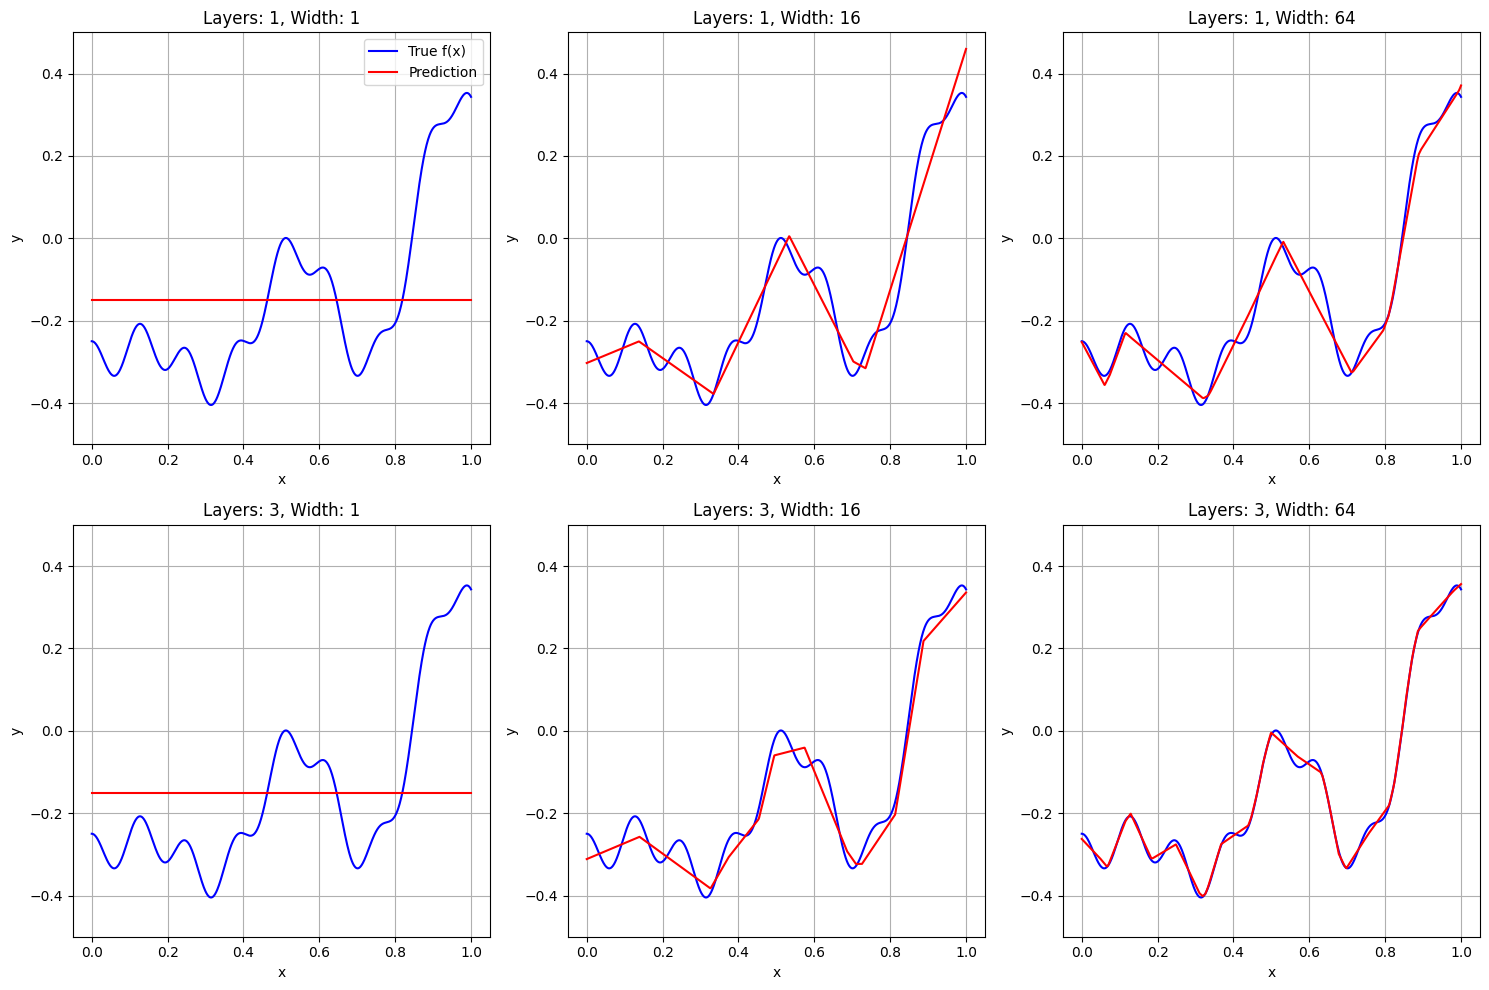

In [9]:
fig, arr = plt.subplots(2, 3, figsize=(15, 10))

for i, num_hidden_layers in enumerate([1, 3]):
    for j, width in enumerate([1, 16, 64]):
        ax = arr[i, j]

        # Plot true function (blue) and prediction (red)
        ax.plot(x, fs, "-b", label="True f(x)")
        ax.plot(x, y_preds[(num_hidden_layers, width)], "-r", label="Prediction")

        # Formatting
        ax.set_title(f"Layers: {num_hidden_layers}, Width: {width}")
        ax.grid()
        ax.set_ylim([-0.5, 0.5])
        ax.set_xlabel("x")
        ax.set_ylabel("y")

        # Add legend only to the first plot to avoid clutter
        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.show()

The plots clearly demonstrate that increasing both the width and depth of the neural network improves its capacity to approximate complex, highly oscillatory functions. A network with a width of 1 completely fails to capture any structure, resulting in a flat line, while increasing the width to 16 allows the model to learn the general trend but not the sharp peaks. Expanding the width to 64 provides enough capacity to capture the high-frequency oscillations. Furthermore, increasing the depth from 1 to 3 hidden layers refines the fit; the 3-layer, 64-width model tracks the true function almost perfectly compared to its 1-layer counterpart.